# Weekly Project 01 - Image Processing

## Part 1

Using the image "appletree.jpg"
1) Can you segment the apples from the tree?
2) Can you get the computer to count how many there are? 
    How close can you get to the ground truth? (there are 26 apples in the image)
3) Can you change the color of one of them?
4) Can you segment the leaves?
    
    
## Part 2

1) Remove the greenscreen and replace the background in "itssp.png".
2) Can you improve the edge with eroding/dilating?


## Weekly Project 01 - Part 1

In [61]:
import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt
from pathlib import Path

#### 1. Can you segment the apples from the tree?

(np.float64(-0.5), np.float64(1599.5), np.float64(1199.5), np.float64(-0.5))

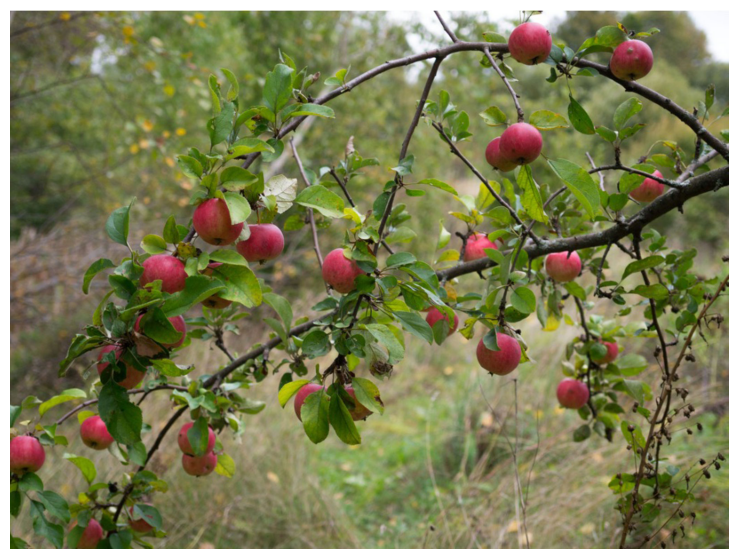

In [62]:
image_path = Path("appletree.jpg")
apples_bgr = cv2.imread(str(image_path))

# OpenCV stores images in BGR order rather than RGB so we swap the ordering of the channels, 
# because `plt.imshow(image)` expects `image` to be in RGB order.
b, g, r = cv2.split(apples_bgr)
apples = cv2.cvtColor(apples_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 7))
plt.imshow(apples)
plt.axis("off")

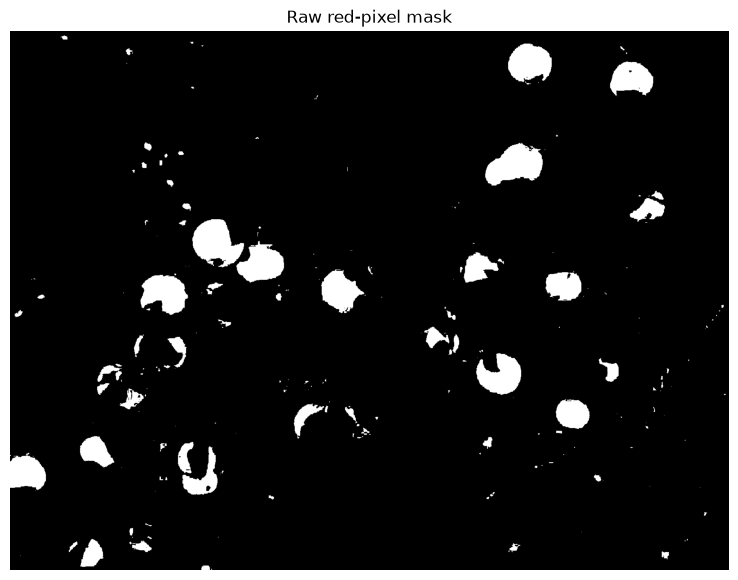

In [63]:
# Do not subtract uint8 arrays directly because negative values would wrap around.
# Select pixels where red is clearly stronger than both green and blue.
red_score = r.astype(np.int16) - np.maximum(g, b).astype(np.int16)
raw_mask = (red_score > 30).astype(np.uint8) * 255

plt.figure(figsize=(10, 7))
plt.imshow(raw_mask, cmap="gray")
plt.title("Raw red-pixel mask")
plt.axis("off");

(np.float64(-0.5), np.float64(1599.5), np.float64(1199.5), np.float64(-0.5))

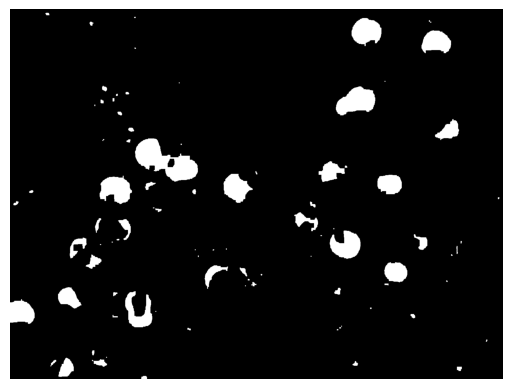

In [64]:
small_kernel = np.ones((3, 3), np.uint8)
large_kernel = np.ones((13, 13), np.uint8)

# Opening = erosion then dilation (to remove small white noise)
clean_mask = cv2.erode(raw_mask, small_kernel, iterations=1)
clean_mask = cv2.dilate(clean_mask, small_kernel, iterations=1)

# Closing = dilation then erosion (to fill gaps inside apple regions)
clean_mask = cv2.dilate(clean_mask, large_kernel, iterations=1)
clean_mask = cv2.erode(clean_mask, large_kernel, iterations=1)

plt.imshow(clean_mask, cmap="gray")
plt.axis("off")

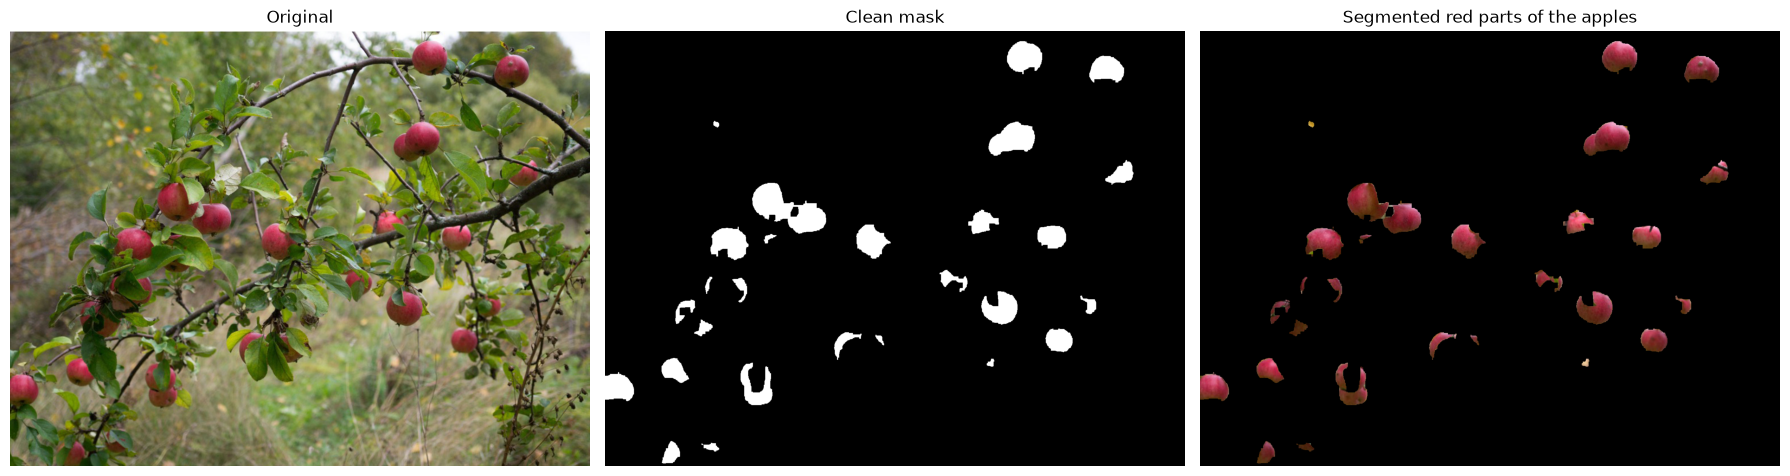

In [65]:
# Give each separate white region in clean_mask a numerical label.
# Label 0 is the black background; stats stores information about every region.
n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(clean_mask)

# Keep only region labels whose area is greater than 200 pixels.
# These sufficiently large red regions are treated as possible apples.
apple_labels = [
    label for label in range(1, n_labels)
    if stats[label, cv2.CC_STAT_AREA] > 200
]

# Make a binary mask: kept regions are white (255), everything else is black (0).
apple_mask = np.isin(labels, apple_labels).astype(np.uint8) * 255

# Copy pixels from the original image only where apple_mask is white.
segmented_apples = cv2.bitwise_and(apples, apples, mask=apple_mask)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(apples)
ax[0].set_title("Original")
ax[1].imshow(apple_mask, cmap="gray")
ax[1].set_title("Clean mask")
ax[2].imshow(segmented_apples)
ax[2].set_title("Segmented red parts of the apples")
for a in ax:
    a.axis("off")
plt.tight_layout()

#### 2. Can you get the computer to count how many there are? 
    How close can you get to the ground truth? (there are 26 apples in the image)

In [66]:
print(f"The computer can count {len(apple_labels)} apples.")

The computer can count 27 apples.


Alternatively:

In [67]:
count, _  = cv2.findContours(apple_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"The computer can count {len(count)} apples.")

The computer can count 27 apples.


The algorithm detected 27 regions instead of the 26 ground-truth apples. This overcount likely occurs because an apple is split into two disconnected regions, or because a higher intensity background region is incorrectly classified as an apple (probably a non-apple region has survived the mask and is counted as an apple. Such an example can be found close to the left top corner).

#### 3. Can you change the color of one of them?


(np.float64(-0.5), np.float64(1599.5), np.float64(1199.5), np.float64(-0.5))

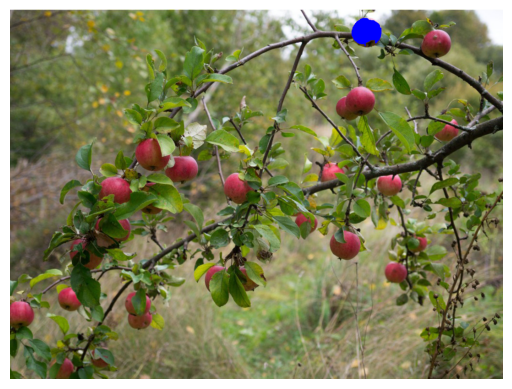

In [68]:
recolored = apples.copy()
recolored[labels == apple_labels[0]] = [0, 0, 255]

plt.imshow(recolored)
plt.axis("off")

#### 4. Can you segment the leaves?


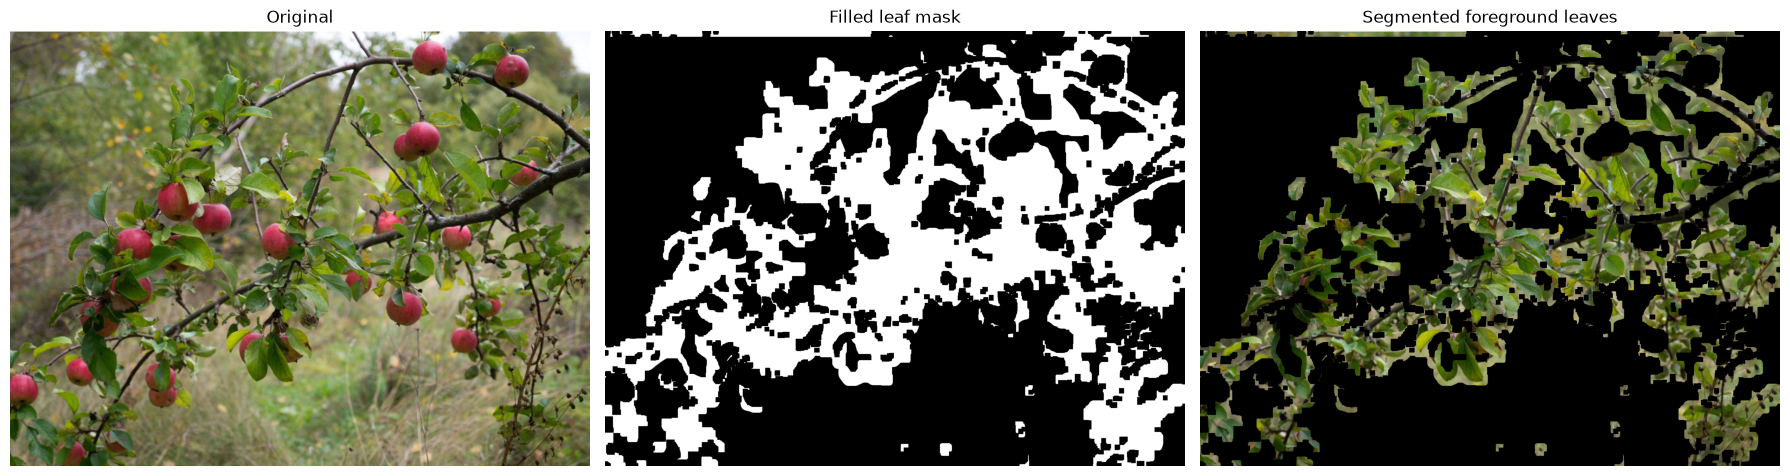

In [69]:
# Select green pixels
hsv = cv2.cvtColor(apples, cv2.COLOR_RGB2HSV)
green_mask = cv2.inRange(
    hsv,
    (25, 70, 30),
    (90, 255, 255)
)

# Find sharp regions to reduce the blurry background
gray = cv2.cvtColor(apples, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(gray, threshold1 = 100, threshold2 = 200)
sharpness = cv2.GaussianBlur(edges, (31, 31), 0)
sharp_mask = (sharpness > 20).astype(np.uint8) * 255

# Expand sharp regions to include the smoother centers of leaves
focus_kernel = np.ones((21, 21), np.uint8)
sharp_mask = cv2.dilate(sharp_mask, focus_kernel, iterations=1)

# Pixels must be green and near a sharp region
leaf_mask = cv2.bitwise_and(green_mask, sharp_mask)

# Fill small gaps inside the leaves
fill_kernel = np.ones((13, 13), np.uint8)
leaf_mask = cv2.dilate(leaf_mask, fill_kernel, iterations=1)
leaf_mask = cv2.erode(leaf_mask, fill_kernel, iterations=1)

# Keep the leaves and make everything else black
segmented_leaves = cv2.bitwise_and(apples, apples, mask=leaf_mask)

# Display the results
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(apples)
ax[0].set_title("Original")

ax[1].imshow(leaf_mask, cmap="gray")
ax[1].set_title("Filled leaf mask")

ax[2].imshow(segmented_leaves)
ax[2].set_title("Segmented foreground leaves")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

The image contains green pixels in both the foreground and the background, so colour alone is not enough to separate the foreground leaves. The background is noticeably blurrier, so we thought that we need to combine green colour with image sharpness. Our segmentation is not perfect because the foreground leaves and background vegetation contain very similar green pixel values.

First, the image is converted from RGB to HSV. HSV makes it easier to select green colours because hue is separated from brightness. `cv2.inRange()` creates a binary mask in which pixels inside the selected green range are white and all other pixels are black.

Next, the image is converted to grayscale and Canny edge detection is applied. Focused foreground leaves generally produce clearer and stronger edges than the blurry background.

The sharp-region mask is dilated because edge detection mainly identifies the outlines and veins of leaves rather than their smooth interiors. Dilation expands these detected regions so that more of each leaf is included.

The green mask and sharp mask are then combined and thus a pixel is selected only when it is both green and located near a sharp region.

Finally, dilation followed by erosion performs a morphological closing operation. This fills small gaps and connects nearby pieces inside the detected leaf regions. The completed mask is applied to the original image keeping the selected leaves while making every other pixel black.

## Weekly Project 01 - Part 2

#### 1. Remove the greenscreen and replace the background in "itssp.png".


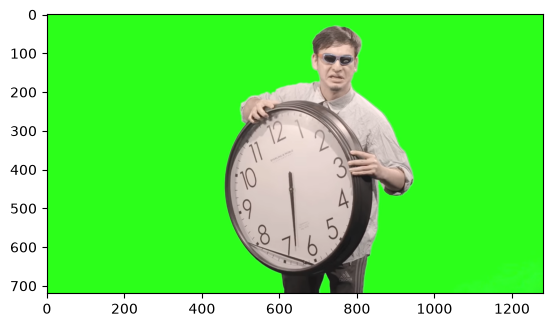

In [70]:
#Setup image path and swap the order to RGB.
path = "ittsp.png"
bgr_image = cv2.imread(path)
b,g,r = cv2.split(bgr_image)
image = cv2.merge([r,g,b])
plt.imshow(image)

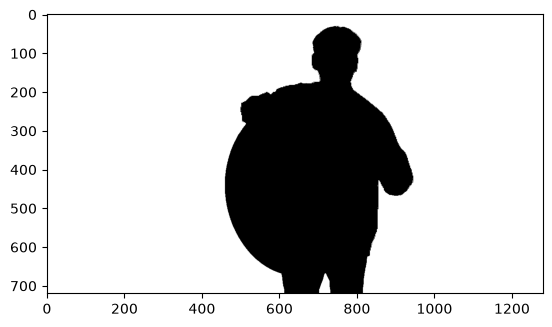

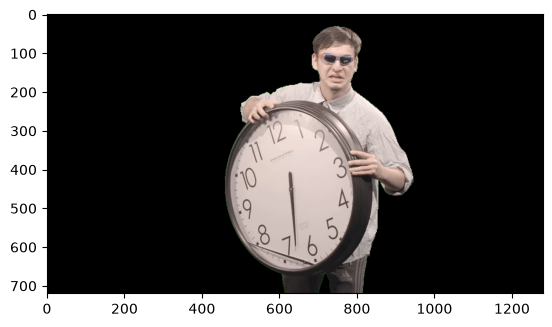

In [71]:
#Define the RGB values for the green background
lower_bound = np.array([0, 150, 0])
upper_bound = np.array([150, 255, 150])

#Create a mask for the green background
mask = cv2.inRange(image, lower_bound, upper_bound)

#Show the mask
plt.imshow(mask, cmap="gray")
plt.show()

#Invert mask to show up the object 
mask_inv = cv2.bitwise_not(mask)

#Remove the green background from the image
removed_green = cv2.bitwise_and(image,image, mask = mask_inv)
plt.imshow(removed_green)

#### Change Background Color

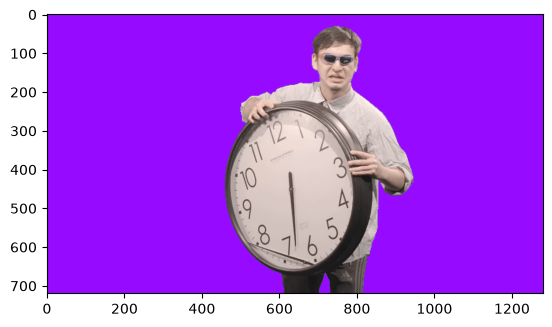

In [72]:
back_color = [150, 10, 255]
background = np.full_like(image, back_color )
#Copy the object to the new background
new_image = cv2.copyTo(image, mask_inv, background)
plt.imshow(new_image)

### 2. Can you improve the edge with eroding/dilating?

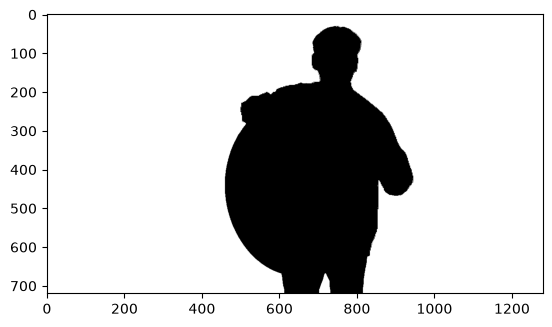

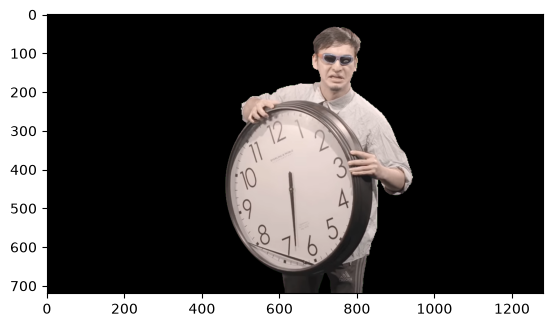

In [73]:
# Define the RGB values for the green background
lower_bound = np.array([0, 150, 0])
upper_bound = np.array([150, 255, 150])

#Create a mask for the green background
mask = cv2.inRange(image, lower_bound, upper_bound)

#Show the mask
plt.imshow(mask, cmap="gray")
plt.show()

#Invert mask to show up the object 
mask_inv = cv2.bitwise_not(mask)

#Define kernel and continue with erosion and dilation.
kernel = np.ones((3, 3))
mask_inv = cv2.erode(mask_inv, kernel, iterations=2)
mask_inv = cv2.dilate(mask_inv, kernel, iterations=1)

#Remove the green background from the image
removed_green = cv2.bitwise_and(image,image, mask = mask_inv)
plt.imshow(removed_green)


After trying different combinations of erosion and dilation, as well as different kernel sizes, we could not observe a significant improvement in the smoothness of the objects. Instead, the applied operations mainly resulted in the loss of important parts of the objects of interest.